# Robusta Experiments
Trying out robusta-hmf on hot star subsamples

## Revision history
- last updated by Nana 2026-06-27

## Notes and bugs and to-dos:
-  Notes: This works off by the data by the notebook called make_hot_star_samples, see notebook for file contents


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from robusta_hmf import Robusta

In [2]:
rng = np.random.default_rng(17)

In [3]:
#define constants
c = 299792.458 #km/s
LN10 = np.log(10.)
MAX_IVAR = 2.5e3

In [4]:
#read in the data and deal with radial velocities


with open('hot_stars_subsample_2026-06-27_data.pkl','rb') as f:
     fluxes, loglam, ivars, continuua, spec_files, rvs = pickle.load(f)
print(fluxes.shape, loglam.shape, ivars.shape, continuua.shape, spec_files.shape)

(2000, 4648) (4648,) (2000, 4648) (2000, 4648) (2000,)


In [5]:
#log lambda values have been corrupted
print(10**loglam)
print(loglam[1:] - loglam[:-1])
print(np.median(loglam[1:] - loglam[:-1]))
delta_log_lambda_pixel = np.median(loglam[1:] - loglam[:-1])

[ 3566.9744  3567.795   3568.6177 ... 10394.412  10396.809  10399.206 ]
[9.9897385e-05 1.0013580e-04 9.9897385e-05 ... 1.0013580e-04 1.0013580e-04
 1.0013580e-04]
9.9897385e-05


In [6]:
#get ready to do pixel shifts
delta_log_lambdas = (rvs / c) / LN10
delta_pixels = np.round(delta_log_lambdas/delta_log_lambda_pixel).astype(int)

print(delta_log_lambdas, delta_pixels)

[ 2.72608685e-05 -1.04017227e-04 -4.34842761e-05 ... -4.27665097e-05
 -6.20446921e-05 -4.43710546e-06] [ 0 -1  0 ...  0 -1  0]


In [7]:
#shift spectra to the rest frame
## johanna is not going to like this

rest_fluxes = np.zeros_like(fluxes) + 1.
rest_ivars = np.zeros_like(ivars)
rest_continuua = np.zeros_like(continuua) + np.nan
for i, dp in enumerate(delta_pixels):
    if dp < 0:
        rest_fluxes[i, -dp:] = fluxes[i, :dp]
        rest_ivars[i, -dp:] = ivars[i, :dp]
        rest_continuua[i, -dp:] = continuua[i, :dp]
        
    elif dp > 0:
        rest_fluxes[i, :-dp] = fluxes[i, dp:]
        rest_ivars[i, :-dp] = ivars[i, dp:]
        rest_continuua[i, :-dp] = continuua[i, dp:]
        
    else:
        rest_fluxes[i, :] = fluxes[i, :]
        rest_ivars[i, :] = ivars[i, :]
        rest_continuua[i, :] = continuua[i, :]


-4
1916


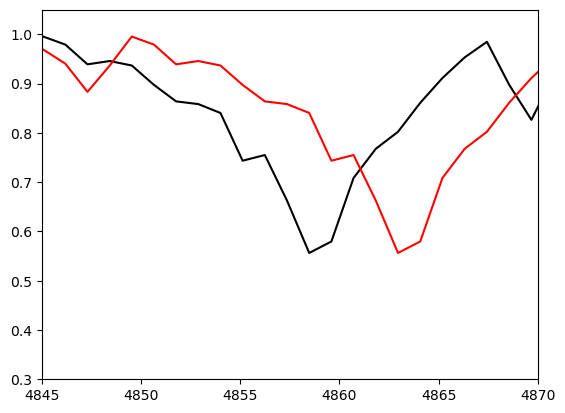

In [8]:
# spot check the above
print(np.min(delta_pixels))
largest_shift = np.argmin(delta_pixels)
print(largest_shift)

plt.plot(10**loglam, fluxes[largest_shift], 'k-')
plt.plot(10**loglam, rest_fluxes[largest_shift], 'r-')
plt.xlim(4845, 4870)
plt.axvline(4471.48)
plt.ylim(0.3,1.05)
plt.show()


In [9]:
#fix nans and infinities
bad = np.logical_not(np.isfinite(rest_fluxes))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_not(np.isfinite(rest_ivars))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = np.logical_or((rest_fluxes > 2.0), (rest_fluxes < 0))
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

bad = rest_ivars > MAX_IVAR
rest_fluxes[bad] = 1
rest_ivars[bad] = 0

In [10]:
print(f"flux median: {np.median(rest_fluxes)}, ivar median{np.median(rest_ivars)}")
print(np.max(rest_fluxes), np.min(rest_fluxes))
print(np.max(rest_ivars), np.min(rest_ivars))

flux median: 0.9968740940524579, ivar median836.9003587059333
1.9998890470995465 5.953785069850951e-06
2499.9404598763913 0.0


In [11]:
# split data into an A sample and a B sample
N, M = fluxes.shape
foo = np.arange(N)
rng.shuffle(foo)
Aindx = foo[:N // 2]
Bindx = foo[N // 2:]


In [12]:
#we are usignt eh rest frame data as our data 
data = rest_fluxes
weights = rest_ivars

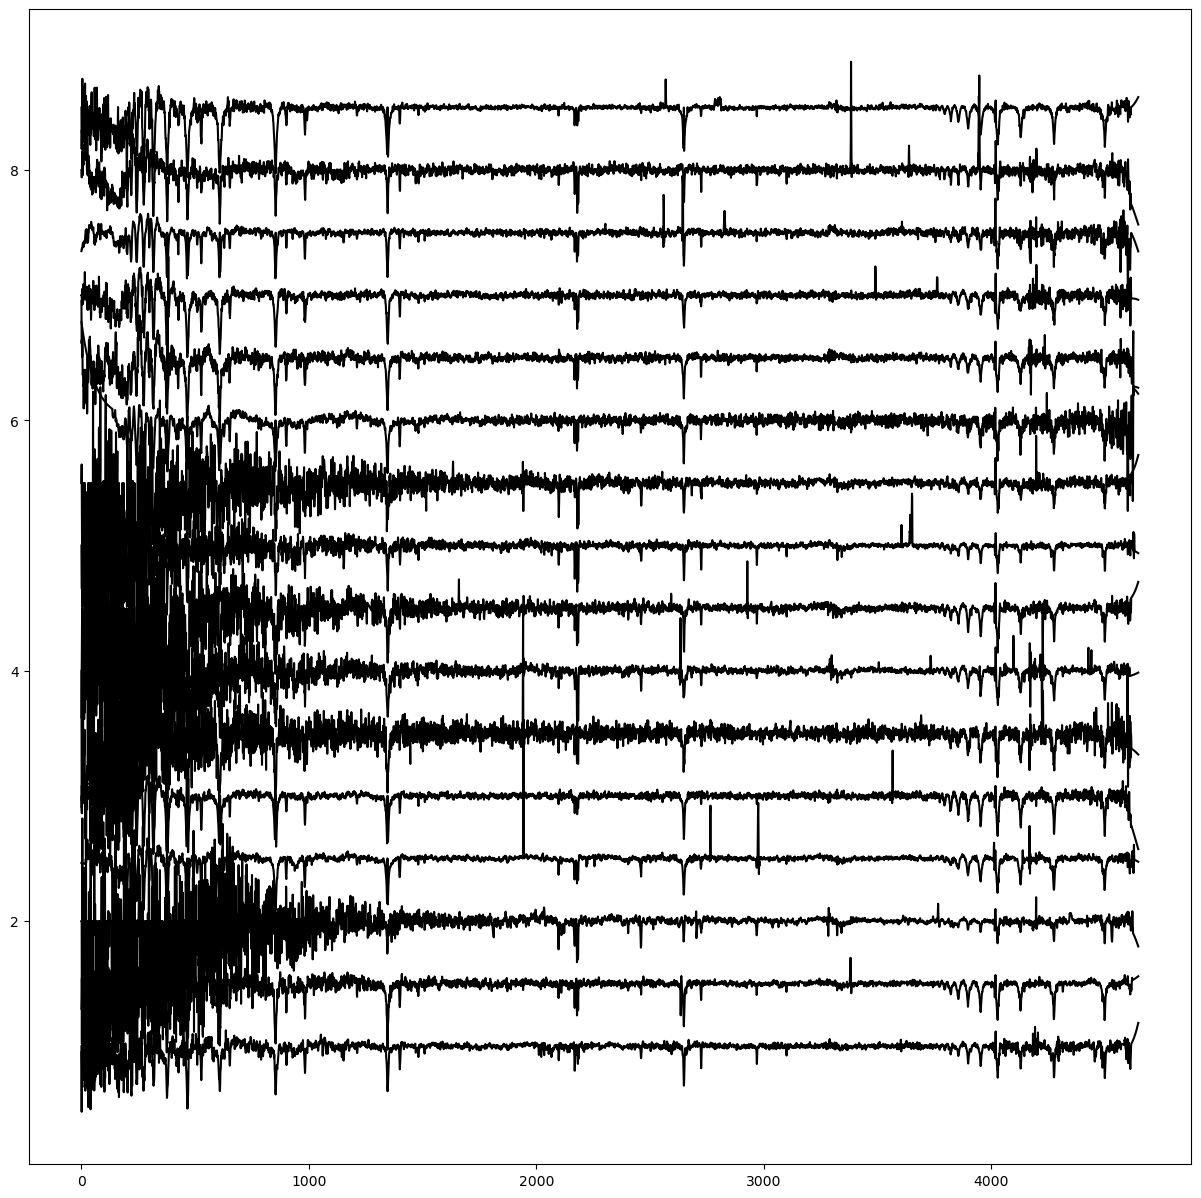

In [13]:
# plot some of the data from sample B just to look
f = plt.figure(figsize=(15, 15))
offset = 0.5
for i in range(16):
    f.gca().plot(data[Bindx[i]] + i * offset, color="k")

In [ ]:
# train two Robusta models
K = 16
foo, bar = 2500, 4500
modelA = Robusta(rank=K, robust=True)
modelB = Robusta(rank=K, robust=True)
fooA = modelA.fit(data[Aindx, foo:bar], weights[Aindx, foo:bar], max_iter = 10000)
#fooB = modelB.fit(data[Bindx, foo:bar], weights[Bindx, foo:bar], max_iter = 10000)


Initializing state... done.


In [ ]:
# plot the eigenspectra
eigsA = modelA.basis_vectors().T
# eigsB = modelB.basis_vectors().T
f = plt.figure(figsize=(15, 15))
offset = 0.2
for i in range(K):
    f.gca().plot(eigsA[i] + i * offset)
    # f.gca().plot(eigsB[i] + i * offset, alpha=0.5)

In [ ]:
# infer at the other (complementary, or held-out) samples
state, _ = modelA.infer(data[Bindx, foo:bar], weights[Bindx, foo:bar])

print(state)
synth = modelA.synthesize(state)
print(synth.shape)

In [ ]:
# plot examples
f = plt.figure(figsize=(15, 15))
offset = 0.5
for i in range(16):
    f.gca().plot(data[Bindx[i], foo:bar] + i * offset, color="k")
    f.gca().plot(synth[i] + i * offset, color="r")

In [ ]:
#make pickle for hogg

file_prefix = "data_weights_subsample_2026-06-29"
with open(file_prefix + ".pkl", "wb") as file:
    pickle.dump((data[Aindx], weights[Aindx]), file)